In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [2]:
DATA_PATH = Path(
    "../data/processed/english_tickets_processed.csv"
)

df = pd.read_csv(DATA_PATH)

df.shape

(16338, 6)

In [3]:
df[
    [
        "text_basic_clean",
        "text_clean",
        "queue",
        "priority"
    ]
].head()

,text_basic_clean,text_clean,queue,priority
0,account disruption dear customer support teamn...,account disruption dear customer support teamn...,Technical Support,high
1,query about smart home system integration feat...,query smart home system integration feature de...,Returns and Exchanges,medium
2,inquiry regarding invoice details dear custome...,inquiry regarding invoice detail dear customer...,Billing and Payments,low
3,question about marketing agency software compa...,question marketing agency software compatibili...,Sales and Pre-Sales,medium
4,feature query dear customer supportnni hope th...,feature query dear customer supportnni hope me...,Technical Support,high


In [4]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["queue"]
)

validation_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["queue"]
)

train_df.shape, validation_df.shape, test_df.shape

((11436, 6), (2451, 6), (2451, 6))

In [5]:
y_train_queue = train_df["queue"]
y_val_queue = validation_df["queue"]
y_test_queue = test_df["queue"]

y_train_priority = train_df["priority"]
y_val_priority = validation_df["priority"]
y_test_priority = test_df["priority"]

In [6]:
X_train_basic = train_df["text_basic_clean"]
X_val_basic = validation_df["text_basic_clean"]
X_test_basic = test_df["text_basic_clean"]

X_train_clean = train_df["text_clean"]
X_val_clean = validation_df["text_clean"]
X_test_clean = test_df["text_clean"]

In [7]:
def evaluate_model(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            average="weighted"
        )
    }

In [8]:
tfidf_basic = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_basic_tfidf = tfidf_basic.fit_transform(X_train_basic)
X_val_basic_tfidf = tfidf_basic.transform(X_val_basic)
X_test_basic_tfidf = tfidf_basic.transform(X_test_basic)

X_train_basic_tfidf.shape

(11436, 43063)

In [9]:
tfidf_clean = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_clean_tfidf = tfidf_clean.fit_transform(X_train_clean)
X_val_clean_tfidf = tfidf_clean.transform(X_val_clean)
X_test_clean_tfidf = tfidf_clean.transform(X_test_clean)

X_train_clean_tfidf.shape

(11436, 41806)

In [10]:
feature_names = tfidf_basic.get_feature_names_out()

len(feature_names)

43063

In [11]:
nb_queue = MultinomialNB()

nb_queue.fit(
    X_train_basic_tfidf,
    y_train_queue
)

nb_queue_val_pred = nb_queue.predict(
    X_val_basic_tfidf
)

nb_queue_result = evaluate_model(
    "Naive Bayes",
    y_val_queue,
    nb_queue_val_pred
)

In [12]:
lr_queue = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

lr_queue.fit(
    X_train_basic_tfidf,
    y_train_queue
)

lr_queue_val_pred = lr_queue.predict(
    X_val_basic_tfidf
)

lr_queue_result = evaluate_model(
    "Logistic Regression",
    y_val_queue,
    lr_queue_val_pred
)

In [13]:
svm_queue = LinearSVC(
    class_weight="balanced"
)

svm_queue.fit(
    X_train_basic_tfidf,
    y_train_queue
)

svm_queue_val_pred = svm_queue.predict(
    X_val_basic_tfidf
)

svm_queue_result = evaluate_model(
    "Linear SVM",
    y_val_queue,
    svm_queue_val_pred
)

In [14]:
queue_results = pd.DataFrame([
    nb_queue_result,
    lr_queue_result,
    svm_queue_result
]).sort_values(
    "F1",
    ascending=False
).reset_index(drop=True)

queue_results

,Model,Accuracy,Precision,Recall,F1
0,Linear SVM,0.680131,0.680118,0.680131,0.679602
1,Logistic Regression,0.535700,0.547408,0.535700,0.536137
2,Naive Bayes,0.384741,0.439608,0.384741,0.301000


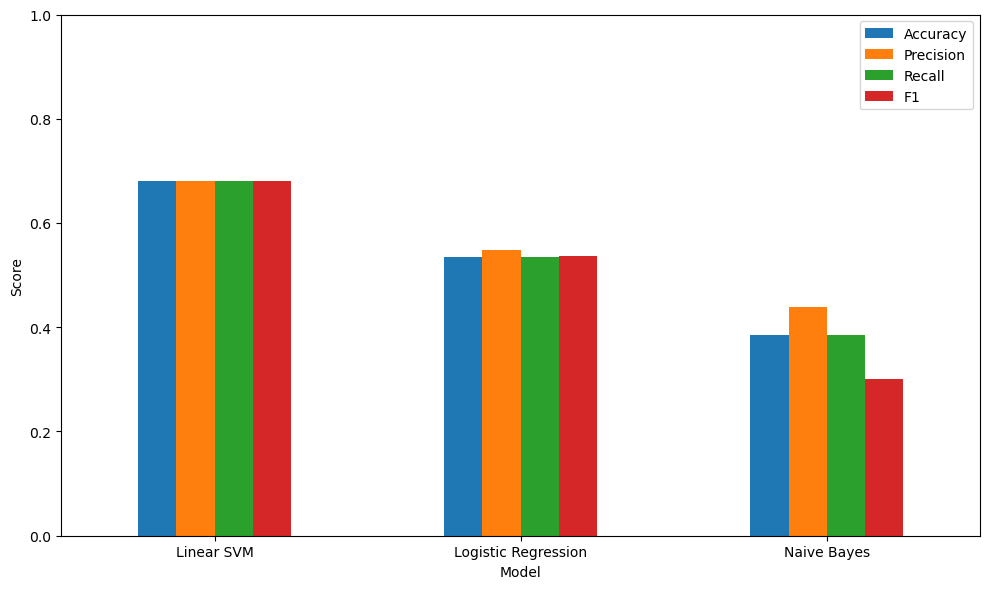

In [15]:
queue_results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
best_queue_model_name = queue_results.iloc[0]["Model"]

best_queue_model_name

'Linear SVM'

In [18]:
queue_train_full_text = pd.concat([
    train_df["text_basic_clean"],
    validation_df["text_basic_clean"]
])

queue_train_full_target = pd.concat([
    y_train_queue,
    y_val_queue
])
final_queue_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_queue_train_full = (
    final_queue_vectorizer
    .fit_transform(queue_train_full_text)
)

X_queue_test = (
    final_queue_vectorizer
    .transform(X_test_basic)
)

In [19]:
if best_queue_model_name == "Naive Bayes":
    final_queue_model = MultinomialNB()

elif best_queue_model_name == "Logistic Regression":
    final_queue_model = LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    )

else:
    final_queue_model = LinearSVC(
        class_weight="balanced"
    )

final_queue_model.fit(
    X_queue_train_full,
    queue_train_full_target
)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,None


In [21]:
final_queue_test_pred = (
    final_queue_model.predict(X_queue_test)
)

print(
    classification_report(
        y_test_queue,
        final_queue_test_pred,
        zero_division=0
    )
)
final_queue_f1 = f1_score(
    y_test_queue,
    final_queue_test_pred,
    average="weighted"
)

final_queue_f1

                                 precision    recall  f1-score   support

           Billing and Payments       0.85      0.86      0.85       239
               Customer Service       0.64      0.63      0.63       361
                General Inquiry       0.86      0.69      0.77        36
                Human Resources       0.73      0.63      0.68        52
                     IT Support       0.65      0.65      0.65       292
                Product Support       0.64      0.66      0.65       461
          Returns and Exchanges       0.68      0.59      0.63       123
            Sales and Pre-Sales       0.64      0.66      0.65        77
Service Outages and Maintenance       0.70      0.82      0.76       100
              Technical Support       0.70      0.70      0.70       710

                       accuracy                           0.69      2451
                      macro avg       0.71      0.69      0.70      2451
                   weighted avg       0.69      0

0.6862332368099328

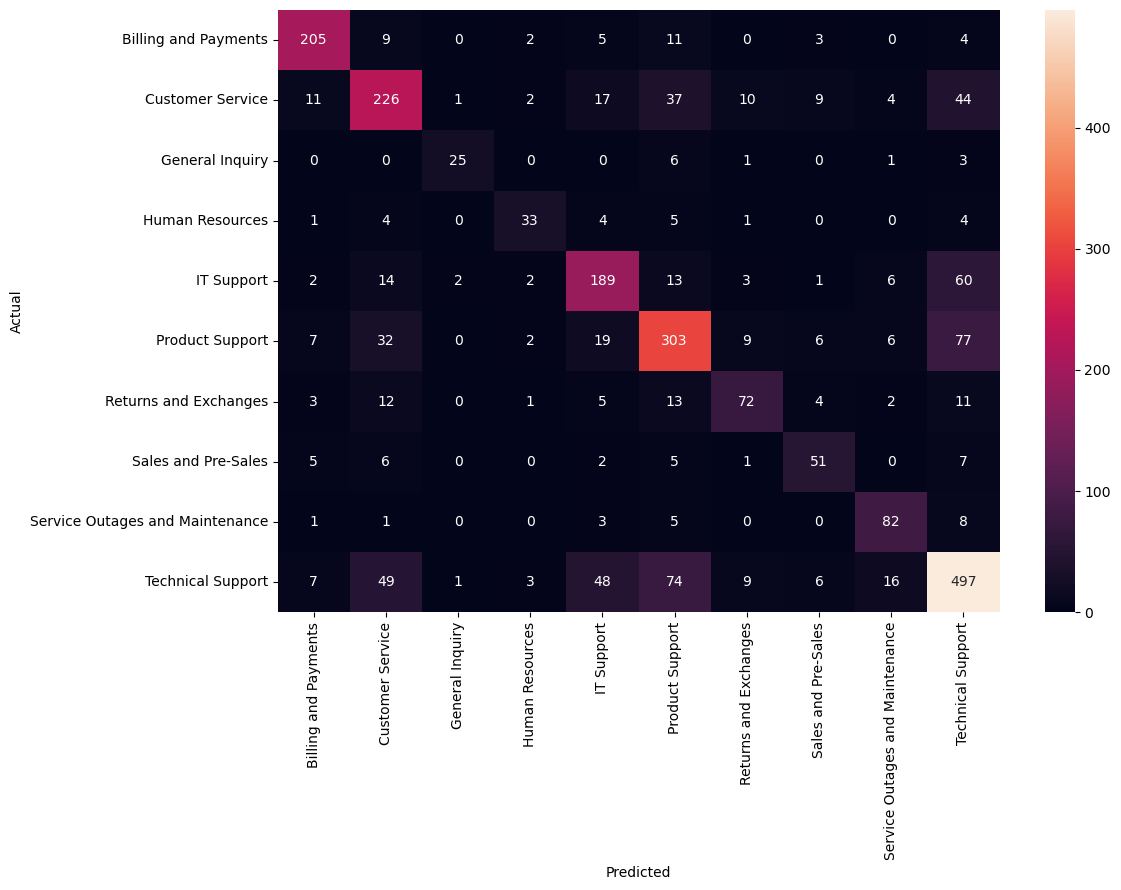

In [22]:
queue_labels = sorted(y_test_queue.unique())

queue_cm = confusion_matrix(
    y_test_queue,
    final_queue_test_pred,
    labels=queue_labels
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    queue_cm,
    annot=True,
    fmt="d",
    xticklabels=queue_labels,
    yticklabels=queue_labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [23]:
nb_priority = MultinomialNB()

nb_priority.fit(
    X_train_basic_tfidf,
    y_train_priority
)

nb_priority_val_pred = nb_priority.predict(
    X_val_basic_tfidf
)

nb_priority_result = evaluate_model(
    "Naive Bayes",
    y_val_priority,
    nb_priority_val_pred
)

In [24]:
lr_priority = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

lr_priority.fit(
    X_train_basic_tfidf,
    y_train_priority
)

lr_priority_val_pred = lr_priority.predict(
    X_val_basic_tfidf
)

lr_priority_result = evaluate_model(
    "Logistic Regression",
    y_val_priority,
    lr_priority_val_pred
)

In [25]:
svm_priority = LinearSVC(
    class_weight="balanced"
)

svm_priority.fit(
    X_train_basic_tfidf,
    y_train_priority
)

svm_priority_val_pred = svm_priority.predict(
    X_val_basic_tfidf
)

svm_priority_result = evaluate_model(
    "Linear SVM",
    y_val_priority,
    svm_priority_val_pred
)

In [26]:
priority_results = pd.DataFrame([
    nb_priority_result,
    lr_priority_result,
    svm_priority_result
]).sort_values(
    "F1",
    ascending=False
).reset_index(drop=True)

priority_results

,Model,Accuracy,Precision,Recall,F1
0,Linear SVM,0.685435,0.685388,0.685435,0.685187
1,Logistic Regression,0.627907,0.631184,0.627907,0.628942
2,Naive Bayes,0.531620,0.635000,0.531620,0.472329


In [27]:
best_priority_model_name = (
    priority_results.iloc[0]["Model"]
)

best_priority_model_name

'Linear SVM'

In [28]:
priority_train_full_text = pd.concat([
    train_df["text_basic_clean"],
    validation_df["text_basic_clean"]
])

priority_train_full_target = pd.concat([
    y_train_priority,
    y_val_priority
])

final_priority_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_priority_train_full = (
    final_priority_vectorizer
    .fit_transform(priority_train_full_text)
)

X_priority_test = (
    final_priority_vectorizer
    .transform(X_test_basic)
)

In [29]:
if best_priority_model_name == "Naive Bayes":
    final_priority_model = MultinomialNB()

elif best_priority_model_name == "Logistic Regression":
    final_priority_model = LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    )

else:
    final_priority_model = LinearSVC(
        class_weight="balanced"
    )

final_priority_model.fit(
    X_priority_train_full,
    priority_train_full_target
)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,None


In [31]:
final_priority_test_pred = (
    final_priority_model.predict(X_priority_test)
)

print(
    classification_report(
        y_test_priority,
        final_priority_test_pred,
        zero_division=0
    )
)
final_priority_f1 = f1_score(
    y_test_priority,
    final_priority_test_pred,
    average="weighted"
)

final_priority_f1

              precision    recall  f1-score   support

        high       0.71      0.75      0.73       923
         low       0.69      0.61      0.65       500
      medium       0.72      0.72      0.72      1028

    accuracy                           0.71      2451
   macro avg       0.70      0.69      0.70      2451
weighted avg       0.71      0.71      0.71      2451



0.7069080258007417

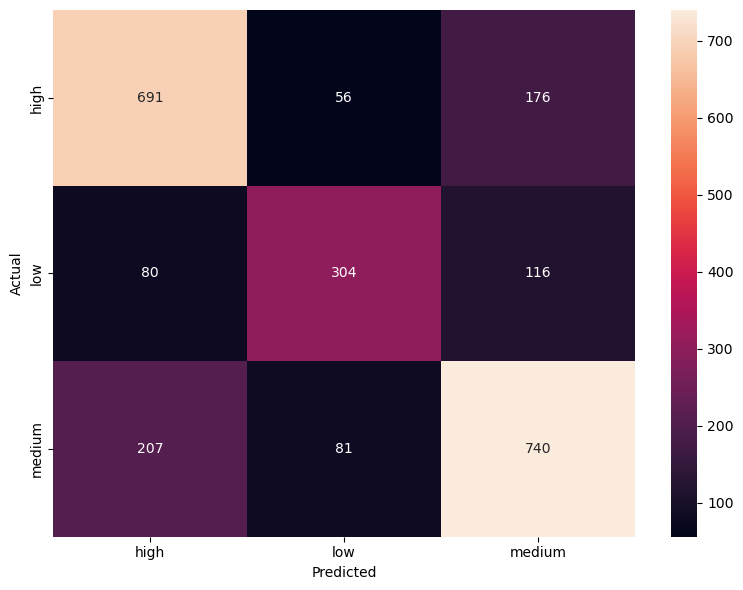

In [32]:
priority_labels = sorted(y_test_priority.unique())

priority_cm = confusion_matrix(
    y_test_priority,
    final_priority_test_pred,
    labels=priority_labels
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    priority_cm,
    annot=True,
    fmt="d",
    xticklabels=priority_labels,
    yticklabels=priority_labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [33]:
clean_lr_queue = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

clean_lr_queue.fit(
    X_train_clean_tfidf,
    y_train_queue
)

clean_lr_pred = clean_lr_queue.predict(
    X_val_clean_tfidf
)

clean_f1 = f1_score(
    y_val_queue,
    clean_lr_pred,
    average="weighted"
)

clean_accuracy = accuracy_score(
    y_val_queue,
    clean_lr_pred
)

clean_precision = precision_score(
    y_val_queue,
    clean_lr_pred,
    average="weighted",
    zero_division=0
)

clean_recall = recall_score(
    y_val_queue,
    clean_lr_pred,
    average="weighted",
    zero_division=0
)

cleaning_comparison = pd.DataFrame([
    {
        "Representation": "Basic Cleaning",
        **lr_queue_result
    },
    {
        "Representation": "Full Cleaning",
        "Model": "Logistic Regression",
        "Accuracy": clean_accuracy,
        "Precision": clean_precision,
        "Recall": clean_recall,
        "F1": clean_f1
    }
])

cleaning_comparison

,Representation,Model,Accuracy,Precision,Recall,F1
0,Basic Cleaning,Logistic Regression,0.535700,0.547408,0.535700,0.536137
1,Full Cleaning,Logistic Regression,0.540188,0.551088,0.540188,0.541395


In [34]:
error_df = test_df.copy()

error_df["predicted_queue"] = final_queue_test_pred

queue_errors = error_df[
    error_df["queue"] != error_df["predicted_queue"]
]

queue_errors[
    [
        "text_raw",
        "queue",
        "predicted_queue",
        "priority",
        "type"
    ]
].head(20)

,text_raw,queue,predicted_queue,priority,type
4023,Update on Digital Strategy Customer Support ha...,Technical Support,Sales and Pre-Sales,high,Change
7169,Support SaaS Platform Issue Our system has bee...,IT Support,Technical Support,high,Problem
13949,Critical Hospital Data Breach Case Noted Data ...,Returns and Exchanges,Technical Support,high,Incident
6933,Issue with Project Dashboards There are issues...,Product Support,Technical Support,high,Incident
7193,Query on Safeguarding Medical Data with PDFfil...,Billing and Payments,Technical Support,high,Request
3717,Request for Assistance with Data Analytics Can...,Technical Support,Human Resources,medium,Request
10253,Seeking Insights on Smart Home Product Marketi...,Billing and Payments,Product Support,medium,Request
9717,Concerns with SaaS Platform The SaaS platform ...,Technical Support,Service Outages and Maintenance,high,Incident
5231,Marketing Initiative Did Not Achieve Anticipat...,Technical Support,Product Support,high,Incident
13220,Upgraded Security Measures for Software Users ...,Customer Service,Returns and Exchanges,medium,Change


In [35]:
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

joblib.dump(
    final_queue_model,
    MODELS_DIR / "queue_model.joblib"
)

joblib.dump(
    final_queue_vectorizer,
    MODELS_DIR / "queue_tfidf.joblib"
)

joblib.dump(
    final_priority_model,
    MODELS_DIR / "priority_model.joblib"
)

joblib.dump(
    final_priority_vectorizer,
    MODELS_DIR / "priority_tfidf.joblib"
)

['..\\models\\priority_tfidf.joblib']

In [36]:
final_results = pd.DataFrame([
    {
        "Task": "Queue",
        "Model": best_queue_model_name,
        "Test F1": final_queue_f1
    },
    {
        "Task": "Priority",
        "Model": best_priority_model_name,
        "Test F1": final_priority_f1
    }
])

final_results

,Task,Model,Test F1
0,Queue,Linear SVM,0.686233
1,Priority,Linear SVM,0.706908
